<a href="https://colab.research.google.com/github/Malaika944/Regularization/blob/main/Regularization_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import required libraries
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [5]:
#Creates 100 data points,One input feature (X),1 feature is actually useful for predicting y,One output variable (y),Adds random Gaussian noise (std=20) to make it realistic,Fixes the random seed for reproducibility.
x,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

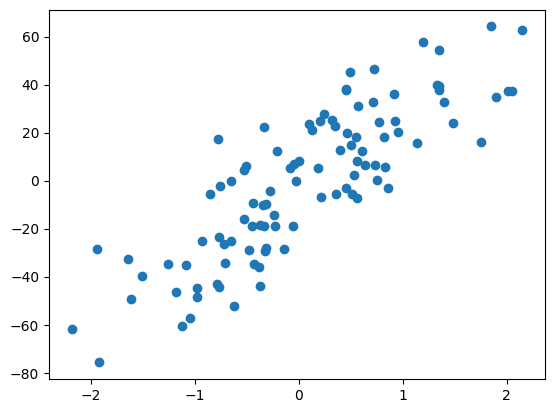

In [6]:
plt.scatter(x,y)

In [8]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()


In [9]:
#Train model
lr.fit(x,y)

LinearRegression()

In [10]:
#slope
lr.coef_

array([27.82809103])

In [11]:
#b
lr.intercept_

np.float64(-2.29474455867698)

In [12]:
#Applied Ridge with alpha =10
from sklearn.linear_model import Ridge
r = Ridge(alpha=10)

In [13]:
#Train the model
r.fit(x,y)

Ridge(alpha=10)

In [14]:
#slope reduced due to alpha value
r.coef_

array([24.9546267])

In [15]:
r.intercept_

np.float64(-2.1269130035235735)

In [16]:
#change alpha
r1= Ridge(alpha=100)
r1.fit(x,y)

Ridge(alpha=100)

In [17]:
r1.coef_

array([12.93442104])

In [18]:
r1.intercept_

np.float64(-1.4248441496033308)

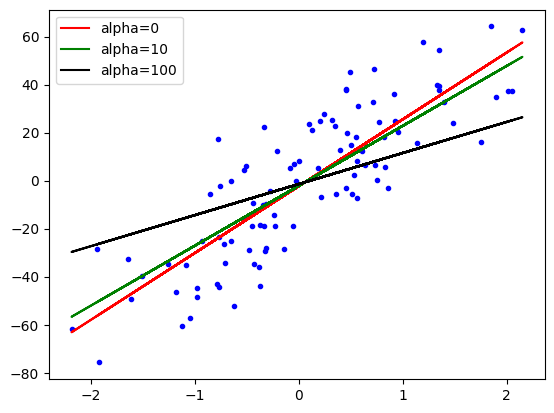

In [25]:
plt.plot(x,y,'b.')#plot data points with blue color
plt.plot(x,lr.predict(x),color='red',label='alpha=0') #draws the regression line (best fit line) on top of your scatter plot.
plt.plot(x,r.predict(x),color='green',label = 'alpha=10')
plt.plot(x,r1.predict(x),color='black',label='alpha=100')
plt.legend() #To show legend.
plt.show()#To remove calculations.

In [39]:
#Create own class
class MyRidge:
  def __init__(self,alpha=0.1):
    self.alpha=alpha
    self.m=None
    self.b=None

  def fit(self,x_train,y_train):
    num=0
    den=0

    for i in range(x_train.shape[0]):
      num = num + ((x_train[i]-x_train.mean()))*(y_train[i]-y_train.mean())
      den = den + (x_train[i]-x_train.mean())* (x_train[i]-x_train.mean())

    self.m= num/(den+self.alpha)
    self.b= y_train.mean()-(self.m*x_train.mean())
    print(self.b,self.m)

In [42]:
reg = MyRidge(alpha=10)

In [43]:
reg.fit(x,y)

[-2.126913] [24.9546267]
